In [14]:
import pandas as pd
import numpy as np
# from tqdm import tqdm
# ============================================================
# 1. Cargar dataset
# ============================================================
# SAVE_DIR = "/content/drive/MyDrive/KYUTECH/Lab research/Research/Anomaly Detection ADCS/Coding/dataset/windowed/"
SAVE_DIR = "./dataset_windows20/"

X = np.load(SAVE_DIR + "X_windows.npy")     # shape: (N, 20, num_features)
y_bin = np.load(SAVE_DIR + "y_binary.npy")  # shape: (N,)
y_ch  = np.load(SAVE_DIR + "y_channel.npy") # shape: (N,), 0 = no fault, 1..18 canal

N, W, F = X.shape

print("=====================================")
print(" Dataset loaded successfully ")
print("=====================================")
print(f"Total windows: {N}")
print(f"Window size: {W}")
print(f"Number of features: {F}")
print(f"Anomalous windows: {sum(y_bin)}")
print(f"Nominal windows: {N - sum(y_bin)}")
print(f"Percentage anomalies: {100 * sum(y_bin)/N:.2f}%")
print("=====================================\n")

 Dataset loaded successfully 
Total windows: 399982
Window size: 20
Number of features: 20
Anomalous windows: 274971
Nominal windows: 125011
Percentage anomalies: 68.75%



In [15]:
import numpy as np

idx_nom = np.where(y_bin == 0)[0]
idx_anom = np.where(y_bin == 1)[0]

print("Nominal windows:", len(idx_nom))
print("Anomalous windows:", len(idx_anom))


Nominal windows: 125011
Anomalous windows: 274971


In [7]:
## Preprocessing

In [16]:
# separar nominales
X_nom = X[y_bin == 0]   # (N_nom, 20, num_features)
# calcular μ y σ por feature
mean_feat = X_nom.mean(axis=(0,1))   # (num_features,)
std_feat  = X_nom.std(axis=(0,1)) + 1e-8
# escalar TODO el dataset
def scale_windows(X, mean, std):
    return (X - mean[None,None,:]) / std[None,None,:]

X_scaled = scale_windows(X, mean_feat, std_feat)


In [17]:
# Balancing dataset
np.random.seed(42)

n_target = len(idx_nom)

idx_anom_sub = np.random.choice(
    idx_anom,
    size=n_target,
    replace=False
)

idx_bal = np.concatenate([idx_nom, idx_anom_sub])
np.random.shuffle(idx_bal)

X_bal = X[idx_bal]
y_bin_bal = y_bin[idx_bal]
y_ch_bal = y_ch[idx_bal]

print("Balanced dataset:")
print("X:", X_bal.shape)
print("Binary labels:", np.bincount(y_bin_bal))


Balanced dataset:
X: (250022, 20, 20)
Binary labels: [125011 125011]


In [18]:
def variance_based_detector(window, threshold_std=1.0):
    """
    window: numpy array (20 x F)
    Detecta anomalía si algún canal tiene std > threshold
    """
    stds = np.std(window, axis=0)
    return 1 if np.any(stds > threshold_std) else 0


In [31]:
y_pred = np.array([
    variance_based_detector(w, threshold_std=1)
    for w in X_bal
])


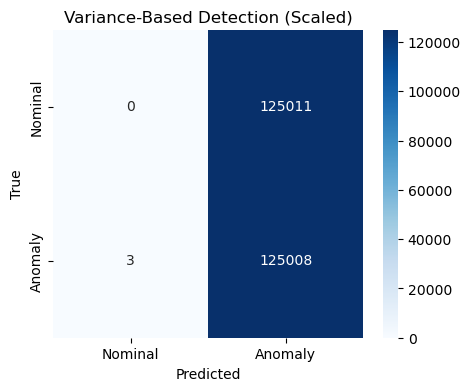

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000    125011
           1     0.5000    1.0000    0.6667    125011

    accuracy                         0.5000    250022
   macro avg     0.2500    0.5000    0.3333    250022
weighted avg     0.2500    0.5000    0.3333    250022



In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_bin_bal, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal","Anomaly"],
    yticklabels=["Nominal","Anomaly"]
)
plt.title("Variance-Based Detection (Scaled)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_bin_bal, y_pred, digits=4))


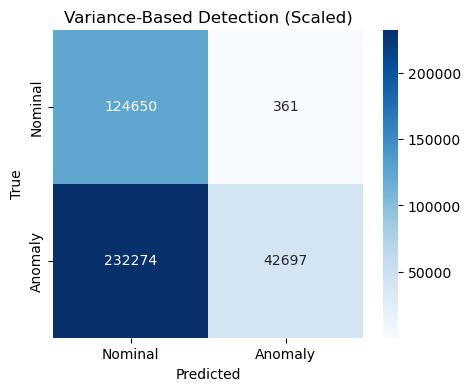

              precision    recall  f1-score   support

           0     0.3492    0.9971    0.5173    125011
           1     0.9916    0.1553    0.2685    274971

    accuracy                         0.4184    399982
   macro avg     0.6704    0.5762    0.3929    399982
weighted avg     0.7908    0.4184    0.3463    399982



In [34]:
y_pred = np.array([
    variance_based_detector(w, threshold_std=1)
    for w in X_scaled
])

cm = confusion_matrix(y_bin, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal","Anomaly"],
    yticklabels=["Nominal","Anomaly"]
)
plt.title("Variance-Based Detection (Scaled)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_bin, y_pred, digits=4))


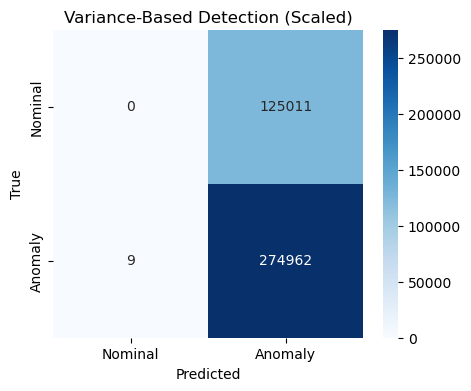

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000    125011
           1     0.6875    1.0000    0.8148    274971

    accuracy                         0.6874    399982
   macro avg     0.3437    0.5000    0.4074    399982
weighted avg     0.4726    0.6874    0.5601    399982



In [35]:
y_pred = np.array([
    variance_based_detector(w, threshold_std=1)
    for w in X
])

cm = confusion_matrix(y_bin, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Nominal","Anomaly"],
    yticklabels=["Nominal","Anomaly"]
)
plt.title("Variance-Based Detection (Scaled)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_bin, y_pred, digits=4))
